In [63]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import missingno as msno


In [64]:
HERE = os.path.abspath('')      
DATA_DIR = os.path.join(HERE, "data")
PATH = os.path.join(DATA_DIR, "ai_productivity_dataset_final.csv")

In [65]:
df_productivity = pd.read_csv(PATH)
df_productivity.head()

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,2379.11,1514.73,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,709.95,335.27,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2


In [66]:
df_productivity.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


In [67]:
df_productivity.shape

(3248, 34)

In [68]:
df_productivity.info()

<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212 non-null   float64
 15  sla_breach     

In [69]:
df_productivity.columns

Index(['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type',
       'seniority', 'task_complexity_score', 'brief_quality_score',
       'deadline_pressure', 'scope_change_flag', 'pricing_model', 'created_at',
       'delivered_at', 'sla_days', 'sla_breach', 'hours_spent',
       'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors',
       'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit',
       'created_by', 'updated_at', 'task_status', 'workflow_stage',
       'jira_ticket', 'legacy_ai_flag', 'content_version'],
      dtype='str')

In [70]:
df_productivity.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


## Dataset Overview and Descriptive Statistics

The dataset contains 3,248 observations, each representing a single task performed within a business workflow. The unit of analysis is therefore at the task level, enabling a granular assessment of operational performance.

The dataset includes variables related to:
- operational efficiency (e.g., hours_spent, billable_hours),
- AI adoption (e.g., ai_usage_pct),
- quality and process performance (e.g., revisions, errors, rework_hours),
- economic outcomes (e.g., revenue, cost, profit).

---

## Descriptive Statistics

The summary statistics provide initial insights into the distribution and variability of the key variables.

### Profit

The average profit is approximately 349, while the median is lower (around 255), indicating a right-skewed distribution. The presence of strongly negative values (minimum ≈ -8510) suggests that some tasks generate substantial losses. In addition, the high standard deviation (≈ 888) reflects significant variability in profitability across tasks.

This indicates that profit is not uniformly distributed and motivates further investigation into the drivers of both high and low performance.

---

### AI Usage

The average AI usage is approximately 36%, with values ranging from 0% to 93%. This indicates that AI is not uniformly adopted across tasks but varies significantly.

This variability is particularly important, as it enables the analysis of non-linear relationships and the identification of potential threshold effects.

---

### Time and Efficiency

The average time spent per task is approximately 13 hours, with a median of about 11 hours. The presence of extreme values (maximum ≈ 263 hours) suggests the existence of outliers or highly complex tasks.

This implies that efficiency gains from AI may not be homogeneous across different types of tasks.

---

### Rework and Quality

The average rework time is approximately 2.4 hours, with a highly skewed distribution and a maximum value exceeding 57 hours. This suggests that a small number of tasks may generate disproportionately high levels of rework.

This observation is consistent with the hypothesis that quality instability may play a significant role in affecting overall performance.

---

### Data Quality Considerations

Some variables, including ai_usage_pct, rework_hours, and billable_hours, contain missing values. Rather than being treated solely as technical issues, these missing values may reflect real-world data collection limitations or process inefficiencies.

---

## Implications for Further Analysis

The descriptive analysis highlights three key aspects:

1. Profitability is highly variable, suggesting heterogeneous effects across tasks.
2. AI usage is continuous rather than binary, allowing for the exploration of non-linear relationships.
3. Rework appears to be concentrated in a subset of tasks, indicating potential sources of inefficiency.

These observations motivate a deeper investigation into the relationship between AI usage, efficiency, quality, and profitability.

## MISSING VALUES

In [71]:
missing = df_productivity.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

jira_ticket            339
ai_usage_pct           144
outcome_score          133
billable_hours          82
rework_hours            72
brief_quality_score     69
delivered_at            38
sla_days                36
dtype: int64

In [72]:

missing_pct = (df_productivity.isnull().sum() / len(df_productivity)) * 100
missing_pct.sort_values(ascending=False)

jira_ticket              10.437192
ai_usage_pct              4.433498
outcome_score             4.094828
billable_hours            2.524631
rework_hours              2.216749
brief_quality_score       2.124384
delivered_at              1.169951
sla_days                  1.108374
workflow_stage            0.000000
task_status               0.000000
updated_at                0.000000
created_by                0.000000
ai_assisted               0.000000
cost                      0.000000
revenue                   0.000000
legacy_ai_flag            0.000000
errors                    0.000000
revisions                 0.000000
profit                    0.000000
task_id                   0.000000
client                    0.000000
hours_spent               0.000000
sla_breach                0.000000
created_at                0.000000
pricing_model             0.000000
scope_change_flag         0.000000
deadline_pressure         0.000000
task_complexity_score     0.000000
seniority           

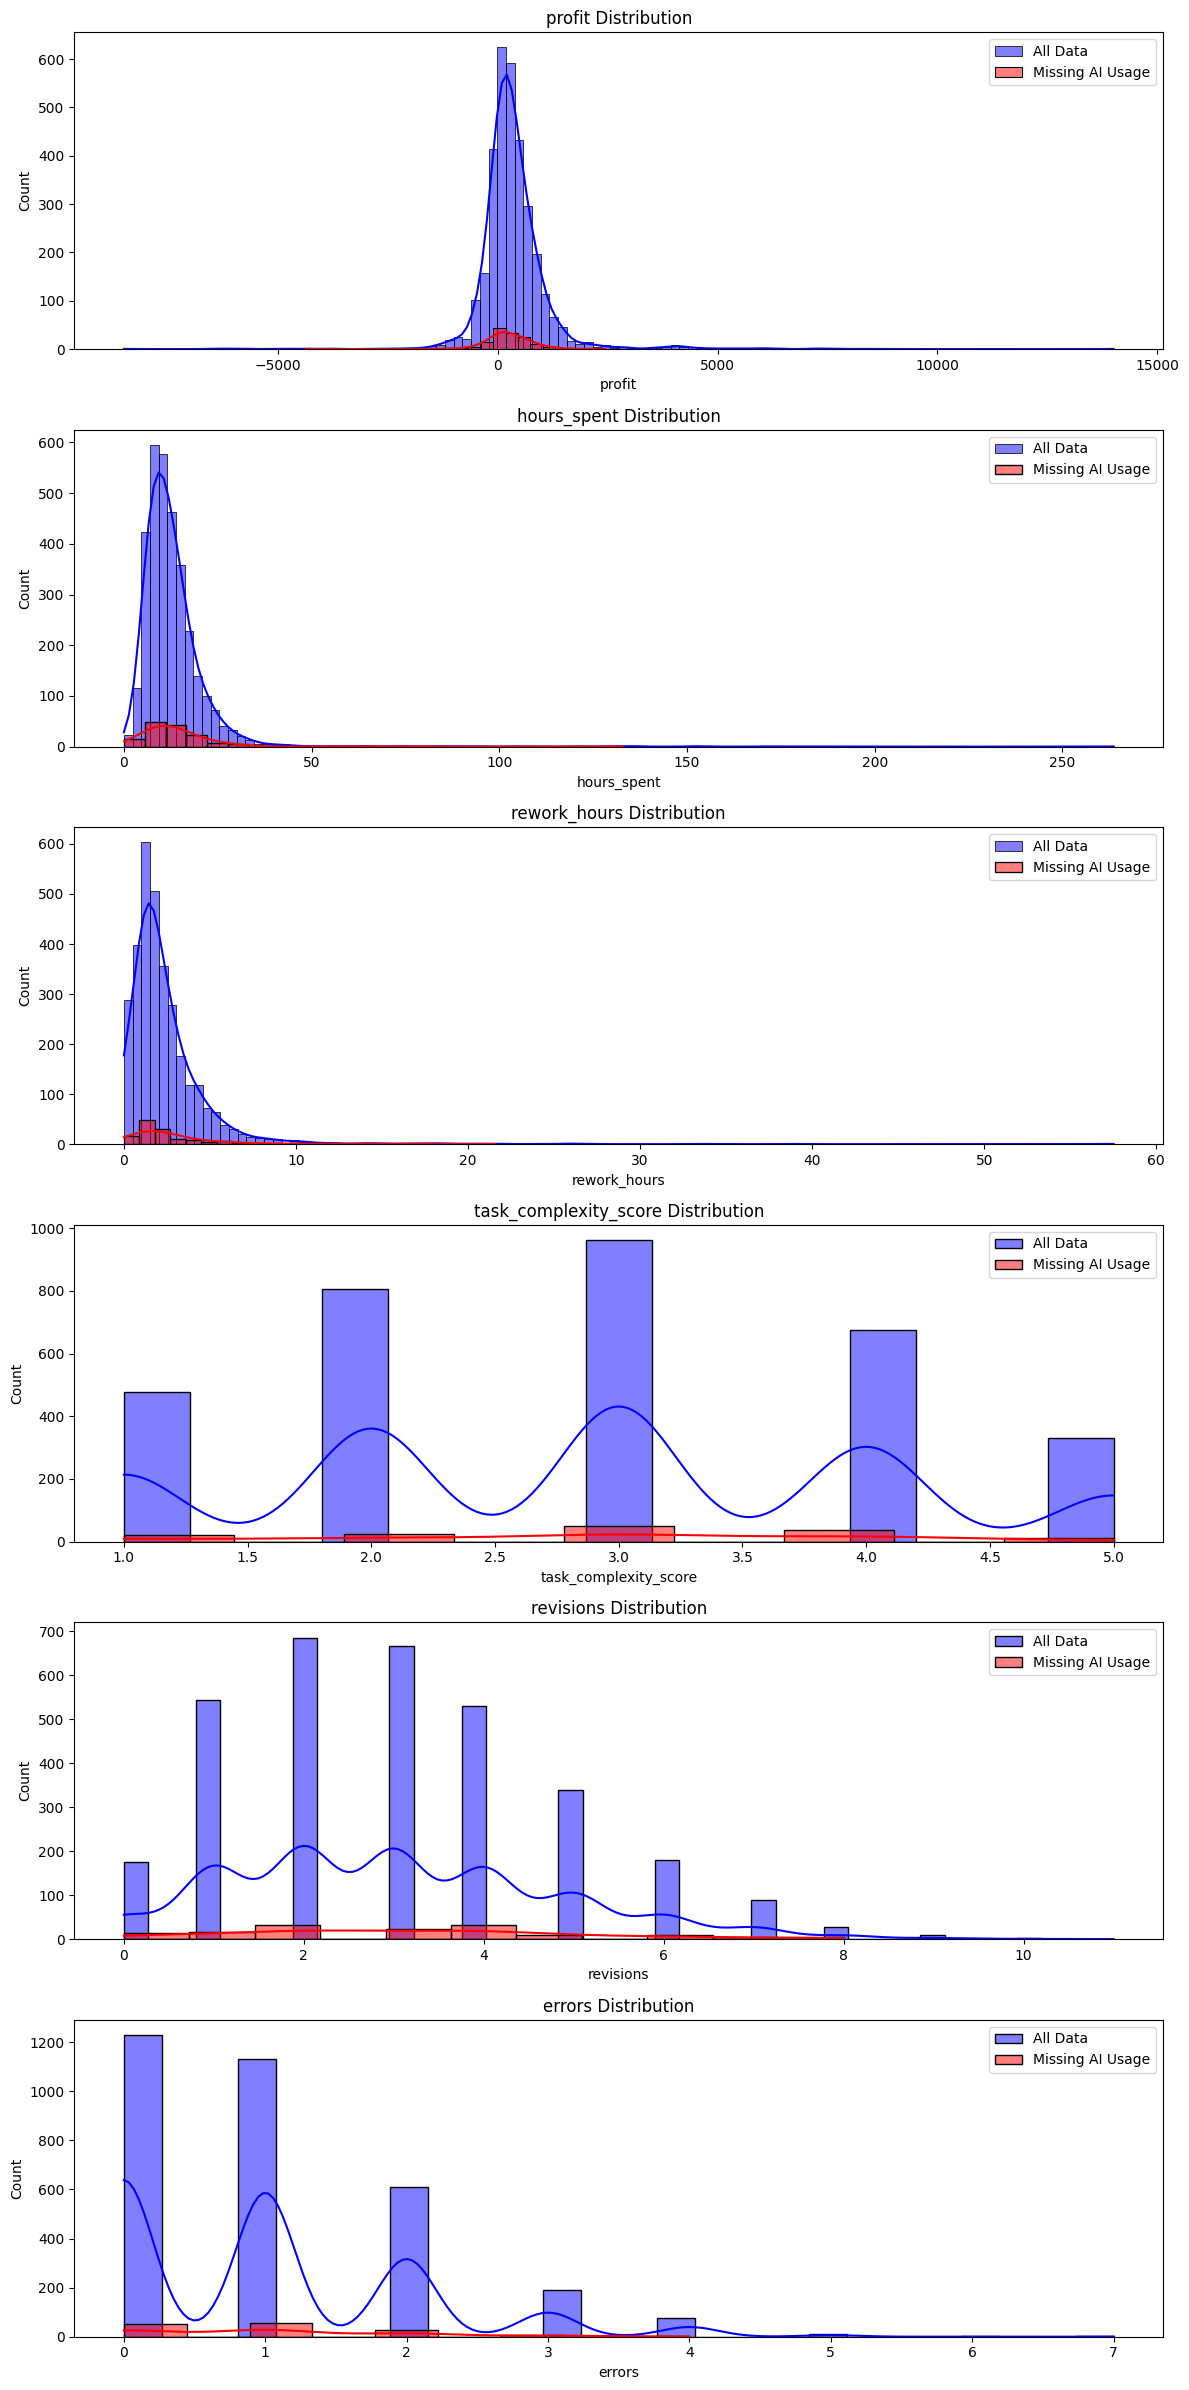

In [73]:

missing_ai_rows = df_productivity[df_productivity['ai_usage_pct'].isnull()]


columns = [
    'profit',
    'hours_spent',
    'rework_hours',
    'task_complexity_score',
    'revisions',
    'errors'
]


fig, axes = plt.subplots(len(columns), 1, figsize=(12, 4 * len(columns)))


for i, column in enumerate(columns):
    
    if column in df_productivity.select_dtypes(include=['int64', 'float64']).columns:
        sns.histplot(df_productivity[column], ax=axes[i], kde=True, color='blue', label='All Data')
        sns.histplot(missing_ai_rows[column], ax=axes[i], kde=True, color='red', label='Missing AI Usage')
    else:
        sns.countplot(data=df_productivity, x=column, ax=axes[i], color='blue', label='All Data')
        sns.countplot(data=missing_ai_rows, x=column, ax=axes[i], color='red', label='Missing AI Usage')
    
    axes[i].set_title(f'{column} Distribution')
    axes[i].set_xlabel(column)
    axes[i].legend()


plt.tight_layout()
plt.show()

<Axes: >

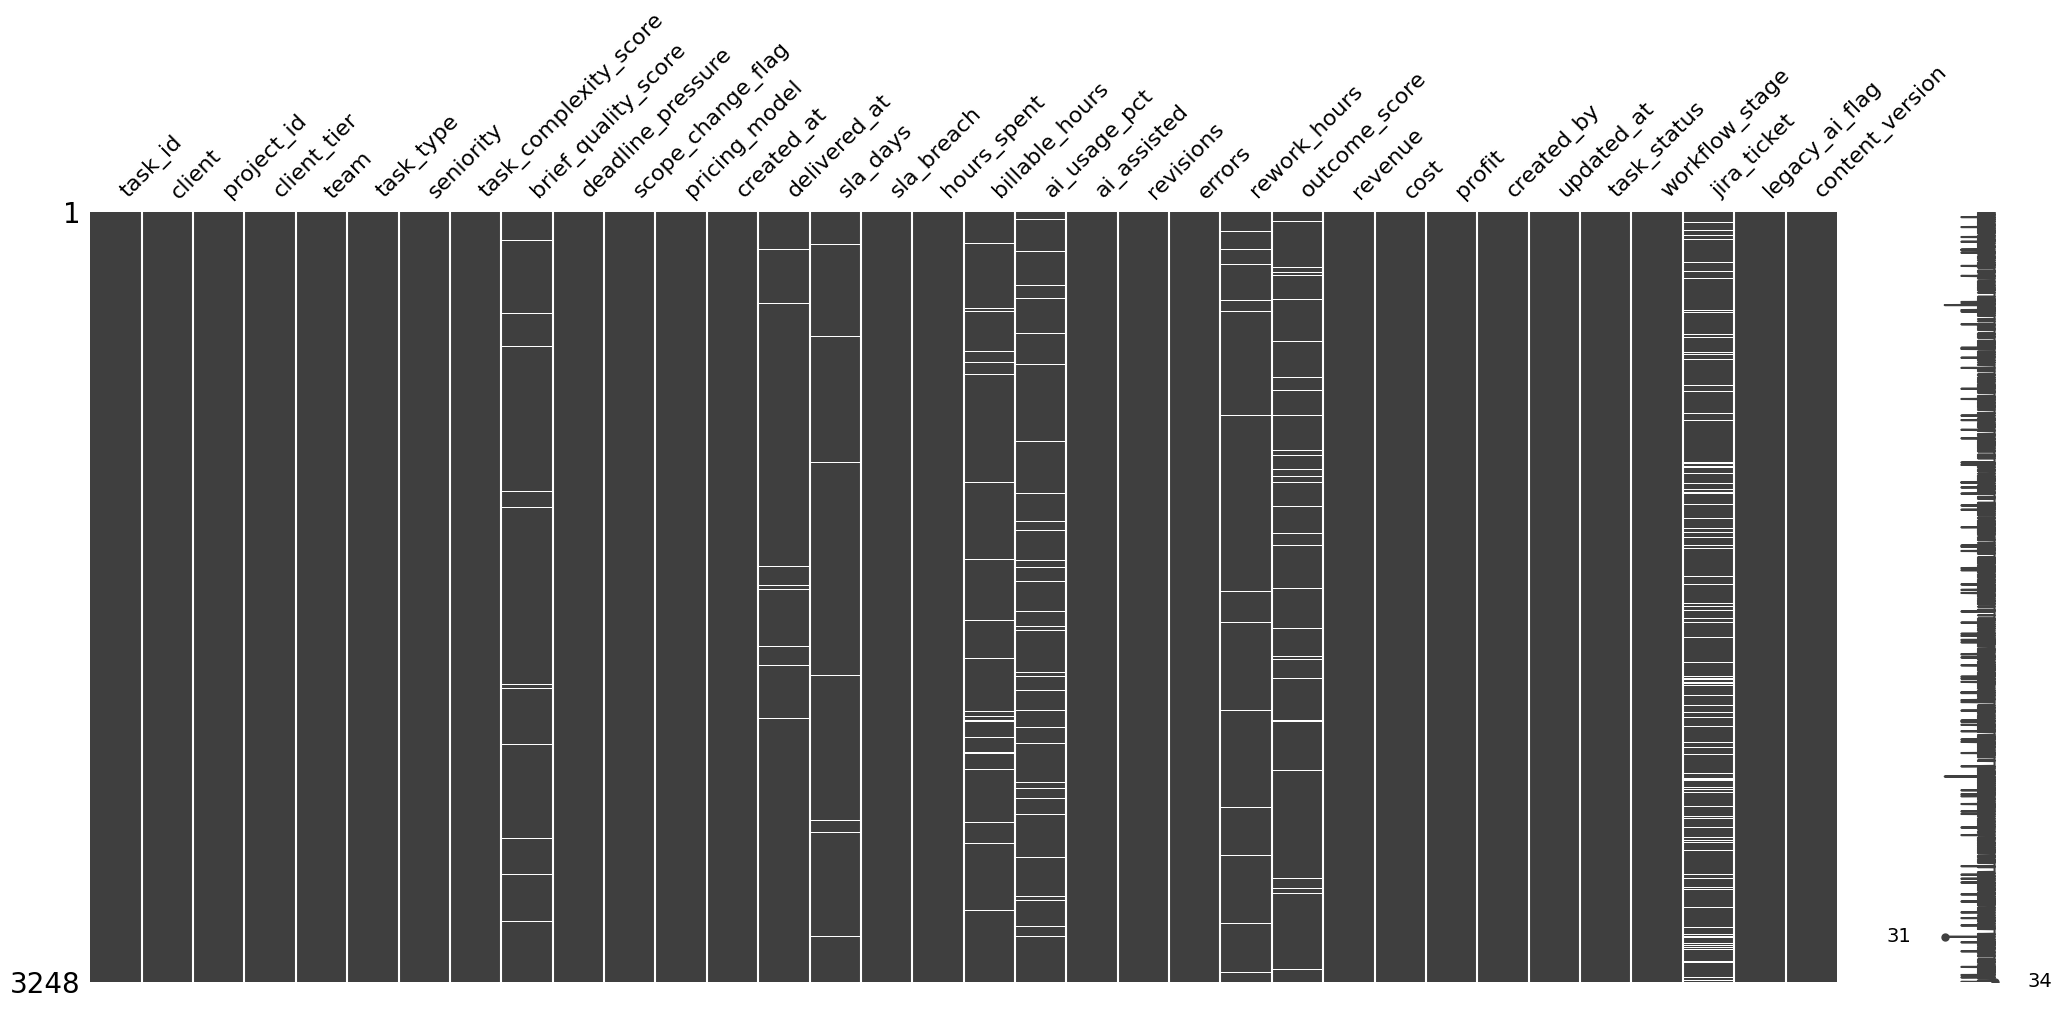

In [74]:
msno.matrix(df_productivity)

**taking care of nans**

In [75]:
df_productivity = df_productivity.drop(columns=['jira_ticket'])


df_productivity['rework_hours'].fillna(0, inplace=True)


df_productivity['billable_hours'].fillna(df_productivity['billable_hours'].median(), inplace=True)
df_productivity['brief_quality_score'].fillna(df_productivity['brief_quality_score'].median(), inplace=True)


df_productivity['outcome_score'].fillna(df_productivity['outcome_score'].median(), inplace=True)


df_ai = df_productivity[df_productivity['ai_usage_pct'].notna()]

/var/folders/sy/rj38yfc5325c80xyvrvsb31m0000gn/T/ipykernel_83073/1587731040.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_productivity['rework_hours'].fillna(0, inplace=True)
/var/folders/sy/rj38yfc5325c80xyvrvsb31m0000gn/T/ipykernel_83073/1587731040.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame

## Target Variable : Profit

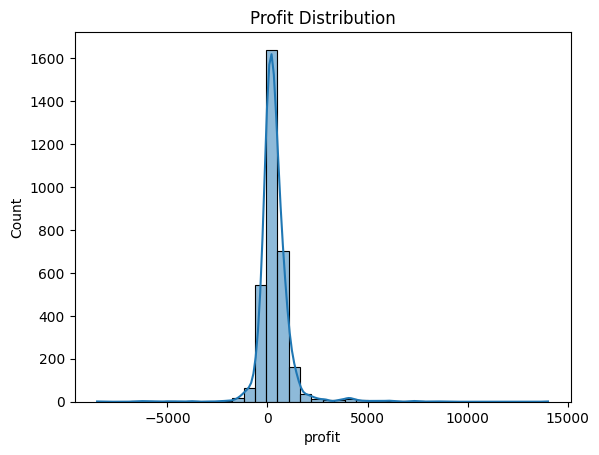

In [76]:
sns.histplot(df_productivity['profit'], bins=40, kde=True)
plt.title("Profit Distribution")
plt.show()

## AI usage 

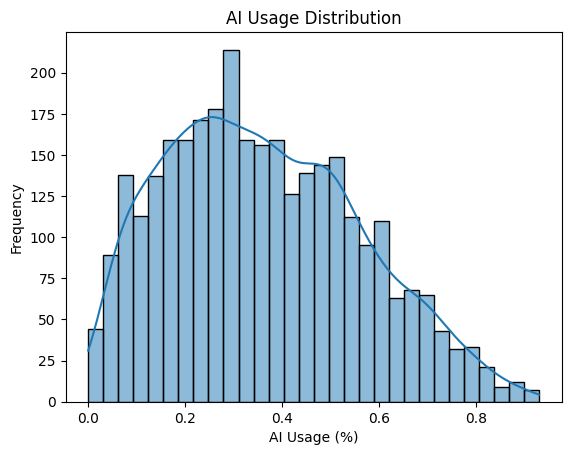

In [77]:
sns.histplot(df_productivity['ai_usage_pct'], bins=30, kde=True)
plt.title("AI Usage Distribution")
plt.xlabel("AI Usage (%)")
plt.ylabel("Frequency")
plt.show()

In [78]:
df_productivity['ai_usage_pct'].describe()

count    3104.000000
mean        0.361717
std         0.199391
min         0.000000
25%         0.200000
50%         0.340000
75%         0.500000
max         0.930000
Name: ai_usage_pct, dtype: float64

## Missing Values Analysis

The dataset presents a limited but non-negligible amount of missing values, primarily concentrated in a subset of variables.

### Missing Values Overview

The variables with the highest number of missing observations are:

- jira_ticket: 339 (10.44%)
- ai_usage_pct: 144 (4.43%)
- outcome_score: 133 (4.09%)
- billable_hours: 82 (2.52%)
- rework_hours: 72 (2.22%)
- brief_quality_score: 69 (2.12%)
- delivered_at: 38 (1.17%)
- sla_days: 36 (1.11%)

All remaining variables exhibit negligible or zero missingness.

---

### Interpretation

The presence of missing values is not uniformly distributed across variables. In particular:

- **jira_ticket** shows the highest proportion of missing values, likely reflecting tracking or logging inconsistencies rather than operational dynamics.
- **ai_usage_pct**, **rework_hours**, and **outcome_score** are directly related to the core dimensions of the analysis (AI usage, quality, and performance), making their missingness particularly relevant.
- **billable_hours** and **brief_quality_score** suggest potential gaps in process measurement or reporting.

Importantly, the absence of missing values in key economic variables such as **revenue**, **cost**, and **profit** ensures that the analysis of financial outcomes remains robust.

---

### Implications for the Analysis

The missingness pattern suggests that data is **not completely random**, but rather linked to specific stages of the workflow or measurement processes.

In particular:

- Missing AI usage may indicate tasks where AI was not tracked or not used explicitly.
- Missing rework or outcome metrics may reflect incomplete evaluation processes.

Given the relatively low percentage of missing values (generally below 5% for most key variables), the dataset remains suitable for analysis without requiring aggressive imputation strategies.

However, special attention will be given to variables such as **ai_usage_pct** and **rework_hours**, as their missingness may introduce bias in the estimation of relationships between AI usage, quality, and profitability.

---
## Missing Data Handling

Missing values were handled using a variable-specific strategy based on their role in the analysis.

The variable `ai_usage_pct`, being central to the research question, was not imputed. Instead, observations with missing AI usage were excluded from analyses involving AI-related relationships.

Variables such as `rework_hours` were imputed with zero, under the assumption that missing values reflect the absence of rework. Other variables with low missingness (e.g., `billable_hours`, `brief_quality_score`) were imputed using the median.

Non-informative variables such as `jira_ticket` were removed.

This approach ensures that data cleaning does not introduce bias in the estimation of the relationship between AI usage, efficiency, and profitability.

## AI Usage Distribution

The variable `ai_usage_pct` represents the proportion of AI involvement in each task.

Descriptive statistics show:

- Mean: 0.36  
- Median: 0.34  
- Standard deviation: 0.20  
- Range: [0.00, 0.93]

This indicates that AI is used at varying intensities across tasks, rather than being a binary feature.

---

### Interpretation

The distribution of AI usage suggests:

- A **moderate average adoption level**, with most tasks involving partial AI assistance.
- A **wide dispersion**, indicating heterogeneous usage patterns across tasks.
- The presence of high-usage observations (above 80%) enables the investigation of extreme cases.

This is particularly important for the analysis, as it allows the exploration of **non-linear effects** and the identification of potential thresholds where AI transitions from beneficial to detrimental in terms of profitability.

---

## Key Takeaway

The dataset is structurally suitable for investigating the relationship between AI usage, efficiency, quality, and profitability.

The combination of:
- low overall missingness,
- continuous AI usage,
- and variability in outcome variables,

provides a strong foundation for identifying the mechanisms underlying the AI productivity paradox.

## efficiency vs quality

**time**


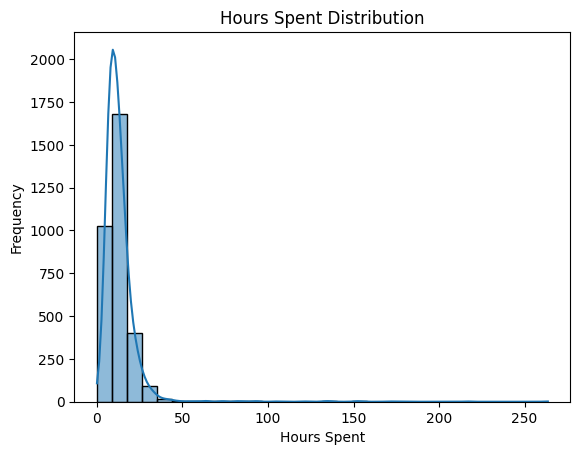

In [79]:
sns.histplot(df_productivity['hours_spent'], bins=30, kde=True)
plt.title("Hours Spent Distribution")
plt.xlabel("Hours Spent")
plt.ylabel("Frequency")
plt.show()

**rework**

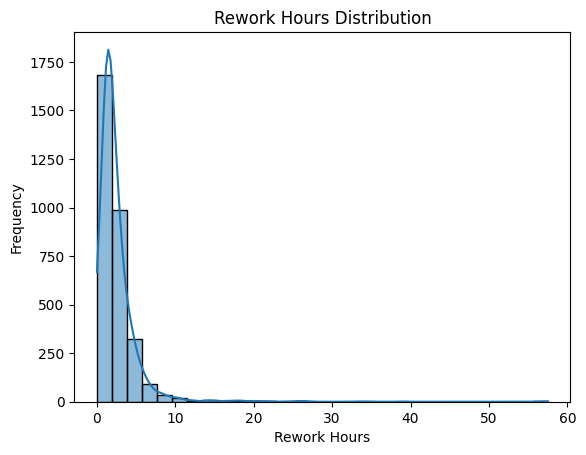

In [80]:
sns.histplot(df_productivity['rework_hours'], bins=30, kde=True)
plt.title("Rework Hours Distribution")
plt.xlabel("Rework Hours")
plt.ylabel("Frequency")
plt.show()

## Correlation

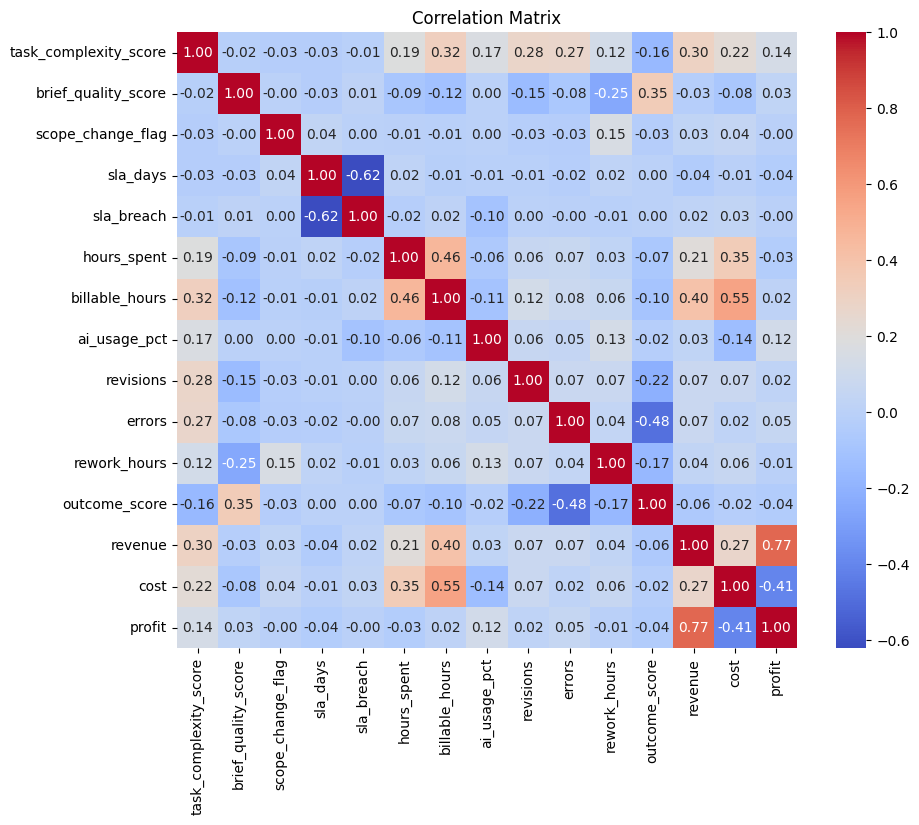

In [81]:
numeric = df_productivity.select_dtypes(include=[np.number])

corr = numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

## Distributional Analysis of Key Variables

### Profit Distribution

The distribution of profit is highly right-skewed, with a concentration of observations around moderate positive values and a long right tail. At the same time, the presence of substantial negative values indicates that some tasks generate significant losses.

This pattern highlights a key characteristic of the dataset: profitability is not uniformly distributed, but rather driven by a combination of typical cases and extreme outcomes.

From an analytical perspective, this suggests that average effects may be misleading, and that it is crucial to account for variability and tail behavior when assessing the impact of AI.

---

### AI Usage Distribution

AI usage exhibits a continuous distribution, with most observations concentrated between 20% and 60%, and a gradual decline toward higher values.

This confirms that AI is not applied in a binary manner, but rather as a scalable input across tasks.

The absence of sharp peaks or discrete clusters suggests that AI adoption is embedded within workflows rather than being limited to specific categories of tasks.

This characteristic is essential, as it allows for the investigation of non-linear relationships and threshold effects in subsequent analyses.

---

### Hours Spent Distribution

The distribution of hours spent is strongly right-skewed, with most tasks requiring relatively low to moderate effort, and a small number of tasks exhibiting very high time requirements.

This indicates the presence of heterogeneous task complexity and suggests that efficiency gains from AI may vary significantly across observations.

In particular, extreme values may correspond to complex or problematic tasks, where the role of AI may differ from standard cases.

---

### Rework Hours Distribution

Rework hours also display a highly skewed distribution, with the majority of tasks requiring limited rework and a small subset exhibiting disproportionately high values.

This pattern is particularly relevant, as it indicates that inefficiencies are concentrated in a limited number of cases.

Such concentration suggests the presence of a “tail risk” effect, where a small number of problematic tasks can have a disproportionate impact on overall performance and profitability.

---

## Missingness and Structural Patterns

The missingness visualization confirms that most variables are largely complete, with missing values concentrated in a limited set of columns, including AI usage, rework, and billing-related variables.

Importantly, the pattern does not appear to be uniformly random across observations, but rather structured, suggesting that missingness may reflect process-specific factors rather than purely technical issues.

This reinforces the need to consider missing values as part of the data-generating process, rather than treating them solely as noise.

---

## Correlation Analysis

The correlation matrix reveals several relevant relationships:

- Profit is strongly positively correlated with revenue (0.77) and negatively correlated with cost (-0.41), as expected.
- Billable hours show a moderate positive correlation with both revenue (0.40) and cost (0.55), indicating their central role in the pricing structure.
- Hours spent are positively correlated with billable hours (0.46), suggesting consistency between operational effort and billing.

However, the relationship between AI usage and profit appears weak (≈ 0.12), indicating that the effect of AI is not directly captured through a simple linear relationship.

Similarly, AI usage shows only a limited association with rework and errors, suggesting that its impact may be indirect or context-dependent.

---

## Key Insight

The combined evidence from the distributions and correlations suggests that:

- AI usage is widespread but heterogeneous.
- Profitability is highly variable and influenced by extreme cases.
- Rework is concentrated in a small subset of tasks.
- The relationship between AI and profit is not linear.

These findings provide initial support for the hypothesis that the impact of AI on performance is mediated by complex interactions between efficiency and quality, rather than being directly observable through simple correlations.

This motivates the need for a deeper analysis of non-linear effects and threshold dynamics.

## Bivariate

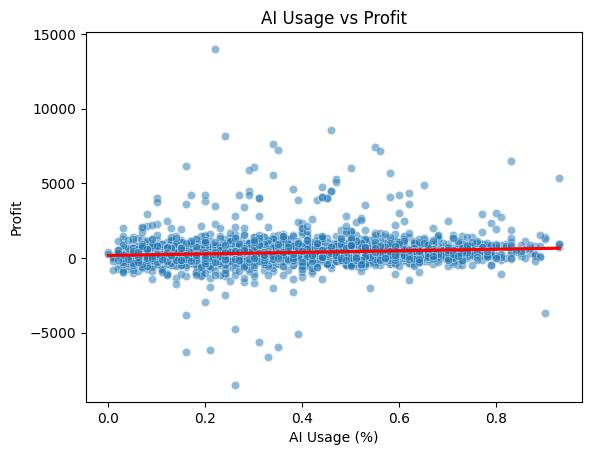

In [83]:

sns.scatterplot(x='ai_usage_pct', y='profit', data=df_productivity, alpha=0.5)


sns.regplot(x='ai_usage_pct', y='profit', data=df_productivity, scatter=False, color='red')

plt.title("AI Usage vs Profit")
plt.xlabel("AI Usage (%)")
plt.ylabel("Profit")
plt.show()

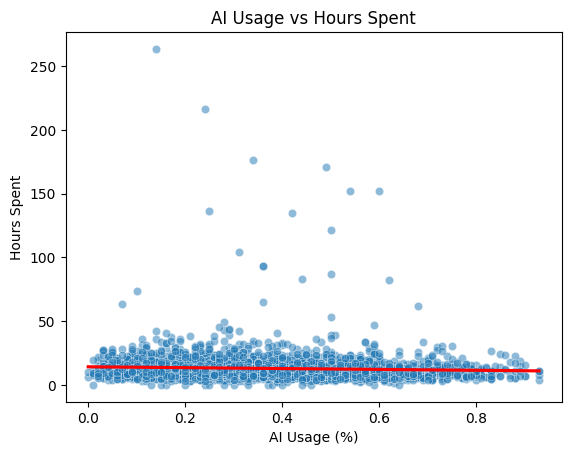

In [84]:
sns.scatterplot(x='ai_usage_pct', y='hours_spent', data=df_productivity, alpha=0.5)
sns.regplot(x='ai_usage_pct', y='hours_spent', data=df_productivity, scatter=False, color='red')

plt.title("AI Usage vs Hours Spent")
plt.xlabel("AI Usage (%)")
plt.ylabel("Hours Spent")
plt.show()

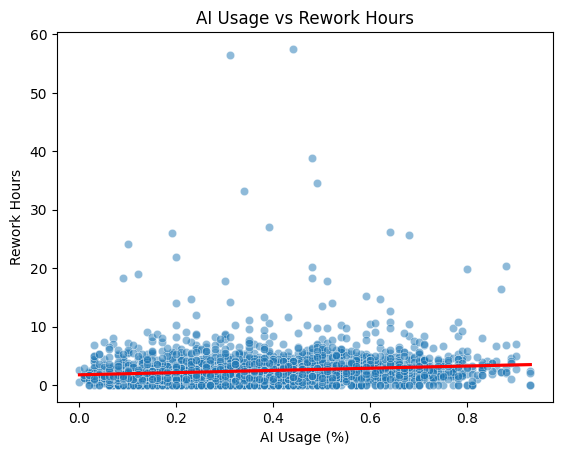

In [85]:
sns.scatterplot(x='ai_usage_pct', y='rework_hours', data=df_productivity, alpha=0.5)
sns.regplot(x='ai_usage_pct', y='rework_hours', data=df_productivity, scatter=False, color='red')

plt.title("AI Usage vs Rework Hours")
plt.xlabel("AI Usage (%)")
plt.ylabel("Rework Hours")
plt.show()

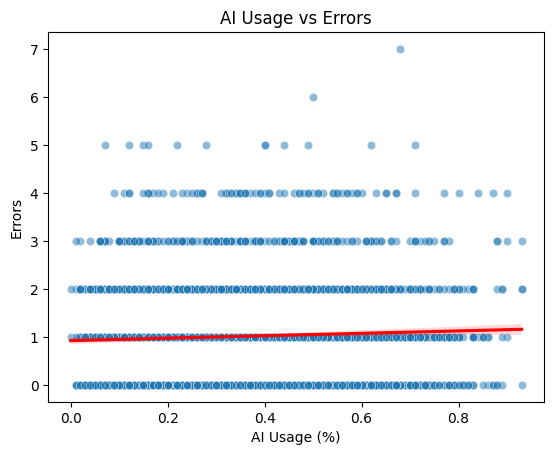

In [86]:
sns.scatterplot(x='ai_usage_pct', y='errors', data=df_productivity, alpha=0.5)
sns.regplot(x='ai_usage_pct', y='errors', data=df_productivity, scatter=False, color='red')

plt.title("AI Usage vs Errors")
plt.xlabel("AI Usage (%)")
plt.ylabel("Errors")
plt.show()

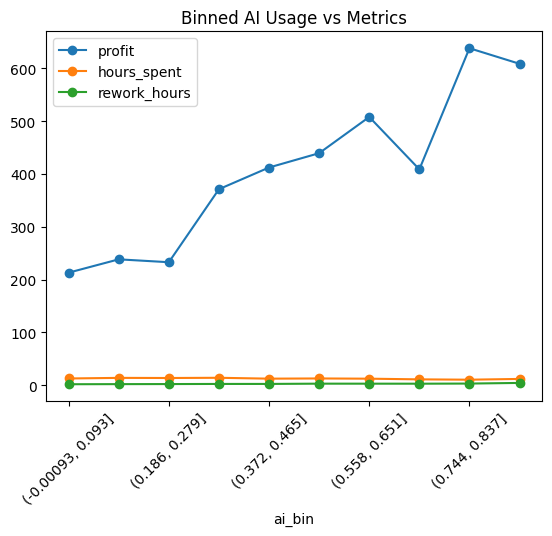

In [87]:

df_productivity['ai_bin'] = pd.cut(df_productivity['ai_usage_pct'], bins=10)


binned = df_productivity.groupby('ai_bin')[['profit','hours_spent','rework_hours']].mean()


binned.plot(marker='o')
plt.title("Binned AI Usage vs Metrics")
plt.xticks(rotation=45)
plt.show()

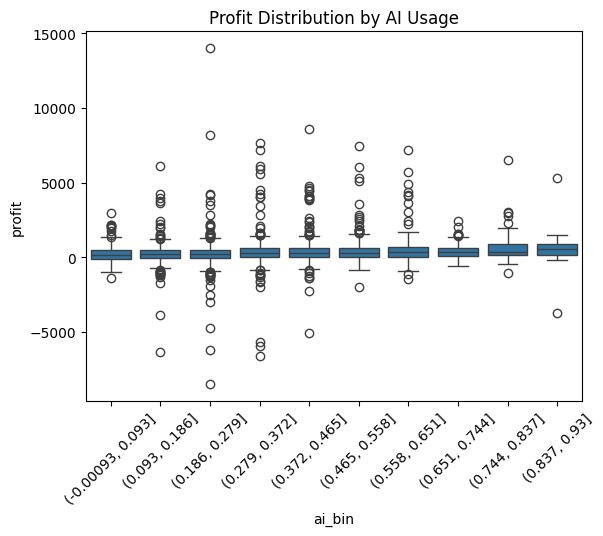

In [88]:
sns.boxplot(x='ai_bin', y='profit', data=df_productivity)
plt.xticks(rotation=45)
plt.title("Profit Distribution by AI Usage")
plt.show()

## Bivariate Analysis

### AI Usage and Profit

The relationship between AI usage and profit appears weak and highly dispersed. The scatter plot shows no clear linear pattern, with profit values widely spread across all levels of AI usage.

While the regression line suggests a slight positive trend, this effect is minimal and obscured by high variability. In particular, both high positive and negative profit values are observed across intermediate levels of AI usage.

This indicates that AI adoption alone is not sufficient to explain profitability, and that additional factors—such as rework or task complexity—likely mediate this relationship.

---

### AI Usage and Efficiency

A clearer pattern emerges when analyzing the relationship between AI usage and hours spent. The regression line shows a negative slope, suggesting that higher AI usage is associated with reduced execution time.

This confirms that AI contributes to improving efficiency by reducing the time required to complete tasks.

However, the presence of significant dispersion and extreme values indicates that this effect is not uniform across all tasks.

---

### AI Usage and Rework

The relationship between AI usage and rework hours is positive but relatively weak. The regression line suggests that higher AI usage is associated with a slight increase in rework.

More importantly, the dispersion increases with AI usage, with several high-rework observations appearing at medium to high levels of AI adoption.

This suggests that while AI may improve speed, it may also introduce variability in output quality, leading to additional corrections in certain cases.

---

### AI Usage and Errors

A similar pattern is observed for errors. While the overall increase is modest, there is a slight upward trend in the number of errors as AI usage increases.

This reinforces the idea that AI may introduce instability in output quality, even if the average effect is not large.

---

## Non-Linear Effects and Aggregated Patterns

The binned analysis provides a clearer view of the underlying relationships.

- **Profit** generally increases with AI usage, but not monotonically. A noticeable drop is observed at intermediate levels before increasing again at higher levels.
- **Hours spent** consistently decrease as AI usage increases, confirming efficiency gains.
- **Rework hours** show a gradual increase, suggesting growing quality-related frictions.

These patterns indicate that the relationship between AI usage and performance is not linear.

---

## Variability and Risk

The boxplot of profit by AI usage highlights a key feature: variability increases with AI usage.

Higher levels of AI adoption are associated with:
- wider interquartile ranges,
- more extreme outliers,
- both very high and very low profit values.

This suggests that AI introduces not only potential gains but also higher risk, making outcomes less predictable.

---

## Key Insight

The results highlight a fundamental trade-off:

- AI improves efficiency by reducing execution time,
- but may increase variability in quality, as reflected in rework and errors,
- resulting in an ambiguous and non-linear impact on profitability.

Rather than uniformly improving performance, AI appears to shift the distribution of outcomes, increasing both upside potential and downside risk.

This provides empirical support for the presence of an AI productivity paradox and motivates the identification of a threshold beyond which AI usage may become detrimental.